In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

In [16]:

DATA_DIR = Path("/Users/mlin2/Desktop/RabLab/tasks/concurrent/data/cleaned_dat")
RAW_DIR04 = Path("/Users/mlin2/Desktop/RabLab/tasks/concurrent/data/raw/raw_dat_20260418")

# clean bl
dat_bl = pd.read_csv(DATA_DIR / "merged_baseline_wDemo.csv")
dat_bl = dat_bl[dat_bl.dx.isin(["EOAD","EOnonAD"])]
dat_bl["log_ptau217"] = np.log(dat_bl["ptau217"]) 
eoad_ids = dat_bl[dat_bl.dx=="EOAD"].subject_label.tolist()

# clean long
def exclude_tx(df):
    return df[df.tx_started == 0].drop(
        columns=["tx_start_date", "tx_started"]
    ) 
def filter_longitudinal(df, eoad_ids, id_col="subject_label"):
    # eoad IDs
    df = df[df[id_col].isin(eoad_ids)].copy()

    # >=2 tps
    valid_ids = (
        df[id_col]
        .value_counts()
        .loc[lambda x: x >= 2]
        .index
    )

    return df[df[id_col].isin(valid_ids)].copy()

ptau_final = exclude_tx(pd.read_csv(DATA_DIR / "ptau_cleaned_20260418.csv"))
tau_final  = exclude_tx(pd.read_csv(DATA_DIR / "tau_cleaned_20260418.csv"))
amy_final  = exclude_tx(pd.read_csv(DATA_DIR / "amy_cleaned_20260418.csv"))
cdr_final  = exclude_tx(pd.read_csv(DATA_DIR / "cdr_cleaned_20260418.csv"))
moca_final = exclude_tx(pd.read_csv(DATA_DIR / "moca_cleaned_20260418.csv"))
ptau_final = filter_longitudinal(ptau_final, eoad_ids)
tau_final  = filter_longitudinal(tau_final,  eoad_ids)
amy_final  = filter_longitudinal(amy_final,  eoad_ids)
cdr_final  = filter_longitudinal(cdr_final,  eoad_ids)
moca_final = filter_longitudinal(moca_final, eoad_ids)
ptau_final["log_ptau217"] = np.log(ptau_final["ptau217"]) 



#long_byptau = pd.read_csv(DATA_DIR / "ptau_ref_long_only_eoad_90d.csv")
#long_byptau["log_ptau217"] = np.log(long_byptau["ptau217"]) 

In [4]:
amy_final.subject_label.nunique()

249

# subject check section with plotly

In [5]:
import plotly.express as px

# Sort for proper line connections
df_sorted = amy_final.sort_values(by=["subject_label", "year_to_baseline_amy"])

fig = px.line(
    df_sorted,
    x="year_to_baseline_amy",
    y="centiloid_wcbl",
    line_group="subject_label",
)

# Make all lines the same color (monochrome)
fig.update_traces(
    line=dict(color="rgba(0,0,0,0.4)", width=1)
)

# Adjust layout: taller, less wide
fig.update_layout(
    title="Centiloid Trajectories by Subject",
    xaxis_title="Years to Amyloid Baseline",
    yaxis_title="Centiloid (WCBL)",
    showlegend=False,
    width=900,   # narrower
    height=900   # taller
)

fig.show()

#can an RA share with me the 2 amyloid PET for LDS0370434 and the 3 amyloid PET for LDS0370497 ? <<< scns!!

In [6]:
""" # section for. cross verifying treatment
tx = pd.read_csv(RAW_DIR04/ "LEADS_EOAD_longit_ATT-identification_2025-03-04.csv")
new_tx = tx[["Tx_ever_received",'Tx_start_date','Amyloid_PET_Date_start','Amyloid_PET_Date_end','ID']]
new_tx.columns = ["txrec",'tx_startdate','Amyloid_PET_Date_start','Amyloid_PET_Date_end','subject_label']
yes_tx = new_tx[new_tx.txrec=="Yes"]
yes_tx = yes_tx[["subject_label","tx_startdate"]].drop_duplicates().sort_values("subject_label")
amy_check = amy_final[amy_final.subject_label.isin(yes_tx.subject_label)][["subject_label","amy_date","centiloid_wcbl"]]
amy_m = amy_check.merge(yes_tx,how="left",on="subject_label")
amy_m[amy_m.tx_startdate<amy_m.amy_date]
tx[tx.ID.isin(yes_tx.subject_label)]
"""

' # section for. cross verifying treatment\ntx = pd.read_csv(RAW_DIR04/ "LEADS_EOAD_longit_ATT-identification_2025-03-04.csv")\nnew_tx = tx[["Tx_ever_received",\'Tx_start_date\',\'Amyloid_PET_Date_start\',\'Amyloid_PET_Date_end\',\'ID\']]\nnew_tx.columns = ["txrec",\'tx_startdate\',\'Amyloid_PET_Date_start\',\'Amyloid_PET_Date_end\',\'subject_label\']\nyes_tx = new_tx[new_tx.txrec=="Yes"]\nyes_tx = yes_tx[["subject_label","tx_startdate"]].drop_duplicates().sort_values("subject_label")\namy_check = amy_final[amy_final.subject_label.isin(yes_tx.subject_label)][["subject_label","amy_date","centiloid_wcbl"]]\namy_m = amy_check.merge(yes_tx,how="left",on="subject_label")\namy_m[amy_m.tx_startdate<amy_m.amy_date]\ntx[tx.ID.isin(yes_tx.subject_label)]\n'

# pasta plot by latest - earliest difference positivity 
as the validity of change is operatinalized as idividual residual / correlation of slope with slope from single model 

In [7]:
cdr_final.subject_label.nunique()

271

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import statsmodels.formula.api as smf



def spaghetti_plot_colored_by_slope(
    df,
    id_col,
    time_col,
    value_col,
    title=None,
    max_subjects=None,
):
    d = df[[id_col, time_col, value_col]].dropna().copy()
    d = d.sort_values([id_col, time_col])

    subjects = d[id_col].unique()
    if max_subjects is not None and len(subjects) > max_subjects:
        rng = np.random.default_rng(0)
        subjects = rng.choice(subjects, size=max_subjects, replace=False)
        d = d[d[id_col].isin(subjects)].copy()

    n_subjects = d[id_col].nunique()
    n_obs = len(d)

    # Track subject-level direction
    n_up = 0
    n_down = 0
    n_same = 0
    counted_subjects = 0

    plt.figure(figsize=(10, 6))

    # --- spaghetti lines ---
    for sid, g in d.groupby(id_col):
        g = g.sort_values(time_col)

        x = g[time_col].values
        y = g[value_col].values

        if len(np.unique(x)) < 2:
            continue

        first_y = y[0]
        last_y = y[-1]

        if np.isclose(last_y, first_y):
            color = "gray"
            n_same += 1
        elif last_y > first_y:
            color = "blue"
            n_up += 1
        else:
            color = "red"
            n_down += 1

        counted_subjects += 1
        plt.plot(x, y, color=color, alpha=0.35, linewidth=1)

    # percentages
    if counted_subjects > 0:
        pct_up = 100 * n_up / counted_subjects
        pct_down = 100 * n_down / counted_subjects
        pct_same = 100 * n_same / counted_subjects
    else:
        pct_up = pct_down = pct_same = np.nan

    # --- MIXED MODEL ---
    try:
        mix_df = d[[time_col, value_col, id_col]].copy()

        # standardize for standardized beta
        mix_df["x_z"] = (mix_df[time_col] - mix_df[time_col].mean()) / mix_df[time_col].std()
        mix_df["y_z"] = (mix_df[value_col] - mix_df[value_col].mean()) / mix_df[value_col].std()

        md = smf.mixedlm("y_z ~ x_z", mix_df, groups=mix_df[id_col])
        mdf = md.fit(reml=False, method="lbfgs", disp=False)

        beta = mdf.params["x_z"]
        pval = mdf.pvalues["x_z"]

        # variance components for R²
        var_fixed = np.var(mdf.fittedvalues)
        var_random = float(mdf.cov_re.iloc[0, 0]) if mdf.cov_re.shape == (1, 1) else np.nan
        var_resid = mdf.scale

        r2_marginal = var_fixed / (var_fixed + var_random + var_resid)
        r2_conditional = (var_fixed + var_random) / (var_fixed + var_random + var_resid)

        # prediction line (fixed effect only)
        xgrid = np.linspace(d[time_col].min(), d[time_col].max(), 200)
        xz = (xgrid - mix_df[time_col].mean()) / mix_df[time_col].std()

        pred_df = pd.DataFrame({"x_z": xz})
        yhat_z = mdf.predict(pred_df)

        # back-transform to original scale
        yhat = yhat_z * mix_df[value_col].std() + mix_df[value_col].mean()

        plt.plot(xgrid, yhat, color="black", linewidth=4)

        # left-side annotation
        """ plt.text(
            0.02, 0.98,
            f"β = {beta:.3f}\np = {pval:.2e}\nR²m = {r2_marginal:.3f}\nR²c = {r2_conditional:.3f}",
            transform=plt.gca().transAxes,
            va="top"
        )"""

        print(f"Standardized beta: {beta:.4f}")
        print(f"p-value: {pval:.4e}")
        print(f"Marginal R²: {r2_marginal:.4f}")
        print(f"Conditional R²: {r2_conditional:.4f}")

    except Exception as e:
        print(f"Mixed model failed: {e}")

    # right-side percentage annotation
    ax = plt.gca()
    ax.text(
        0.98, 0.98,
        f"% increase: {pct_up:.1f}%",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=16,
        color="blue"
    )
    ax.text(
        0.98, 0.93,
        f"% decrease: {pct_down:.1f}%",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=16,
        color="red"
    )
    ax.text(
        0.98, 0.88,
        f"% unchanged: {pct_same:.1f}%",
        transform=ax.transAxes,
        fontsize=16,
        ha="right",
        va="top",
        color="gray"
    )

    plt.xlabel("Year")
    plt.ylabel(value_col)

    base_title = title or f"Spaghetti plot: {value_col}"
    plt.title(f"{base_title} | N subj = {n_subjects}, N obs = {n_obs}")

    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

Standardized beta: 0.0944
p-value: 4.4822e-07
Marginal R²: 0.4448
Conditional R²: 0.9099


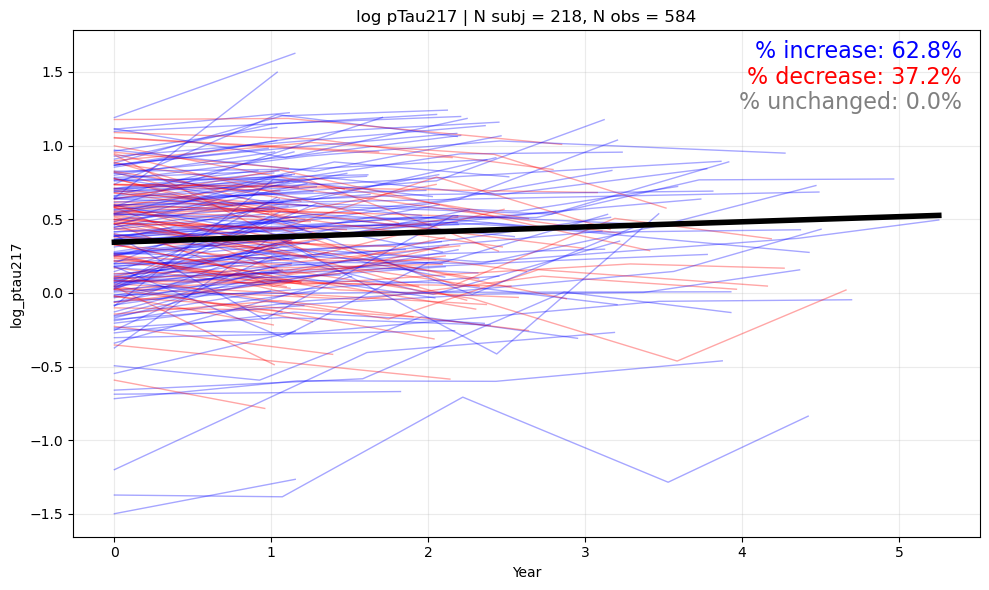

Standardized beta: 0.1703
p-value: 6.7825e-53
Marginal R²: 0.4799
Conditional R²: 0.9649


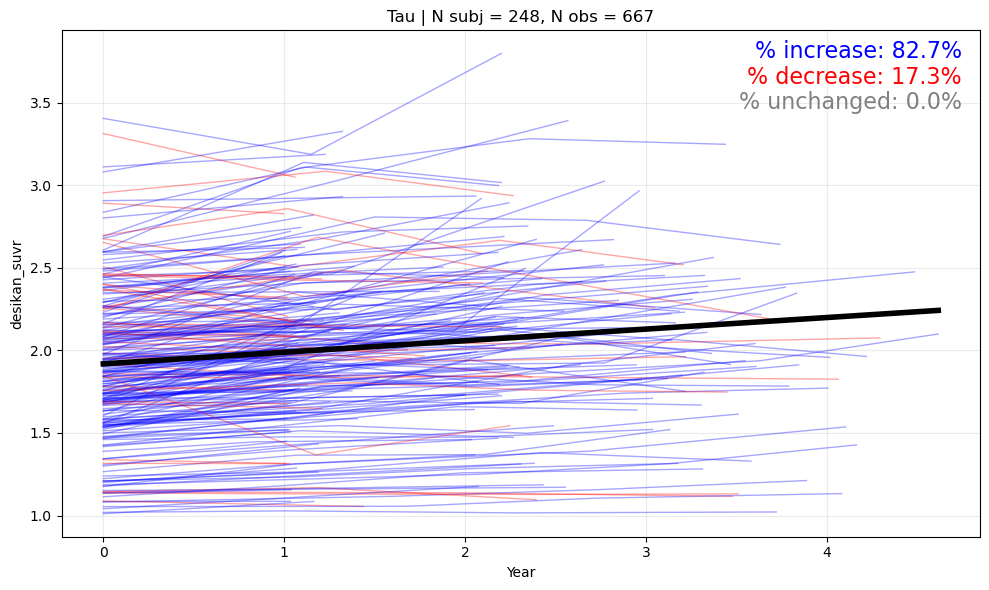

Standardized beta: 0.0869
p-value: 9.5321e-09
Marginal R²: 0.4567
Conditional R²: 0.9296


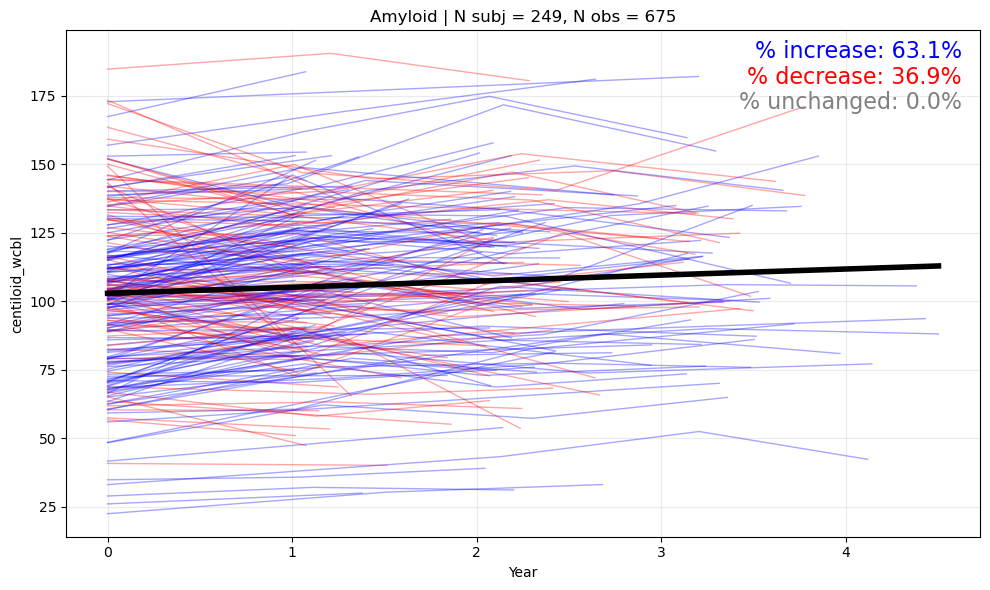

Standardized beta: 0.5775
p-value: 7.8689e-164
Marginal R²: 0.4964
Conditional R²: 0.7931


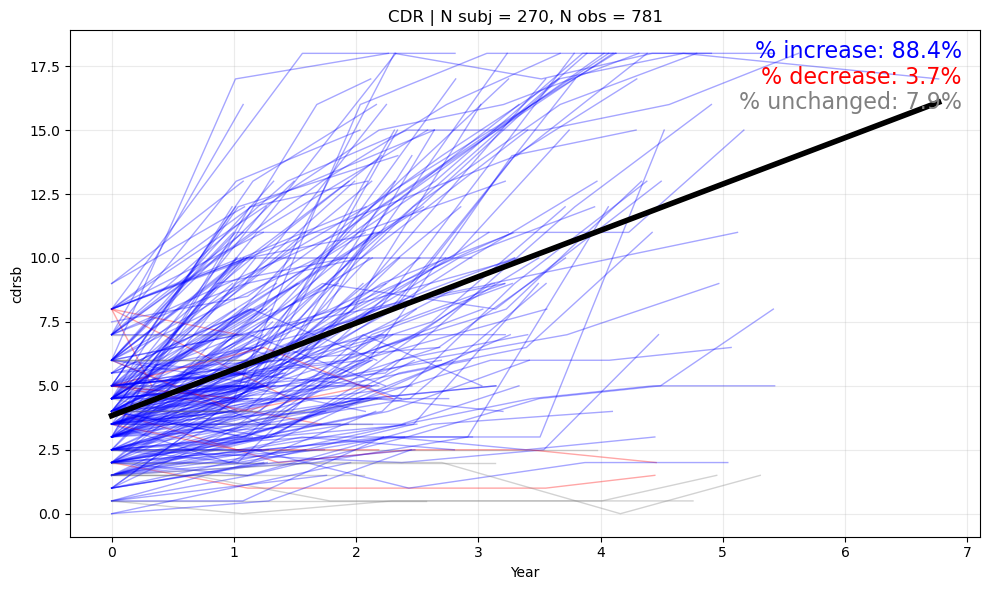

Standardized beta: -0.4281
p-value: 1.5506e-105
Marginal R²: 0.4690
Conditional R²: 0.9013


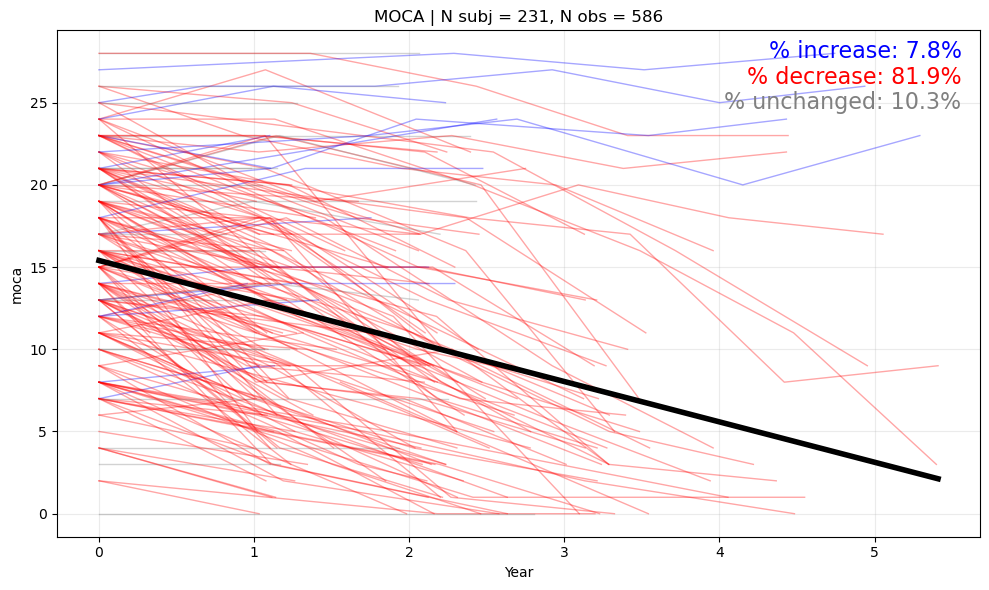

In [13]:
spaghetti_plot_colored_by_slope(ptau_final, "subject_label", "year_to_baseline_ptau", "log_ptau217", "log pTau217")
spaghetti_plot_colored_by_slope(tau_final, "subject_label", "year_to_baseline_tau", "desikan_suvr", "Tau")
spaghetti_plot_colored_by_slope(amy_final, "subject_label", "year_to_baseline_amy", "centiloid_wcbl", "Amyloid")
spaghetti_plot_colored_by_slope(cdr_final, "subject_label", "year_to_baseline_cdr", "cdrsb", "CDR")
spaghetti_plot_colored_by_slope(moca_final, "subject_label", "year_to_baseline_moca", "moca", "MOCA")

# by biomarker color , no trend 

In [14]:

def spaghetti_plot_colored(
    df,
    id_col,
    time_col,
    value_col,
    line_color="steelblue",
    title=None,
    max_subjects=None,
):
    d = df[[id_col, time_col, value_col]].dropna().copy()
    d = d.sort_values([id_col, time_col])

    subjects = d[id_col].unique()
    if max_subjects is not None and len(subjects) > max_subjects:
        rng = np.random.default_rng(0)
        subjects = rng.choice(subjects, size=max_subjects, replace=False)
        d = d[d[id_col].isin(subjects)].copy()

    n_subjects = d[id_col].nunique()
    n_obs = len(d)

    plt.figure(figsize=(10, 6))

    # --- spaghetti lines ---
    for sid, g in d.groupby(id_col):
        g = g.sort_values(time_col)

        x = g[time_col].values
        y = g[value_col].values

        if len(np.unique(x)) < 2:
            continue

        plt.plot(x, y, color=line_color, alpha=0.35, linewidth=1)

    # --- MIXED MODEL ---
    try:
        mix_df = d[[time_col, value_col, id_col]].copy()

        x_mean = mix_df[time_col].mean()
        x_std = mix_df[time_col].std()
        y_mean = mix_df[value_col].mean()
        y_std = mix_df[value_col].std()

        mix_df["x_z"] = (mix_df[time_col] - x_mean) / x_std
        mix_df["y_z"] = (mix_df[value_col] - y_mean) / y_std

        md = smf.mixedlm("y_z ~ x_z", mix_df, groups=mix_df[id_col])
        mdf = md.fit(reml=False, method="lbfgs", disp=False)

        beta = mdf.params["x_z"]
        pval = mdf.pvalues["x_z"]

        # variance components for R²
        var_fixed = np.var(mdf.fittedvalues)
        var_random = float(mdf.cov_re.iloc[0, 0]) if mdf.cov_re.shape == (1, 1) else 0
        var_resid = mdf.scale

        r2_marginal = var_fixed / (var_fixed + var_random + var_resid)
        r2_conditional = (var_fixed + var_random) / (var_fixed + var_random + var_resid)

        # prediction line (fixed effect only)
        xgrid = np.linspace(d[time_col].min(), d[time_col].max(), 200)
        xz = (xgrid - x_mean) / x_std

        pred_df = pd.DataFrame({"x_z": xz})
        yhat_z = mdf.predict(pred_df)

        # back-transform to original scale
        yhat = yhat_z * y_std + y_mean

        plt.plot(xgrid, yhat, color="black", linewidth=4)

        # left-side annotation
        """plt.text(
            0.02, 0.98,
            f"β = {beta:.3f}\np = {pval:.2e}\nR²m = {r2_marginal:.3f}\nR²c = {r2_conditional:.3f}",
            transform=plt.gca().transAxes,
            va="top"
        )"""

        print(f"Standardized beta: {beta:.4f}")
        print(f"p-value: {pval:.4e}")
        print(f"Marginal R²: {r2_marginal:.4f}")
        print(f"Conditional R²: {r2_conditional:.4f}")

    except Exception as e:
        print(f"Mixed model failed: {e}")

    plt.xlabel("Year")
    plt.ylabel(value_col)

    base_title = title or f"Spaghetti plot: {value_col}"
    plt.title(f"{base_title} | N subj = {n_subjects}, N obs = {n_obs}")

    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


Standardized beta: 0.0944
p-value: 4.4822e-07
Marginal R²: 0.4448
Conditional R²: 0.9099


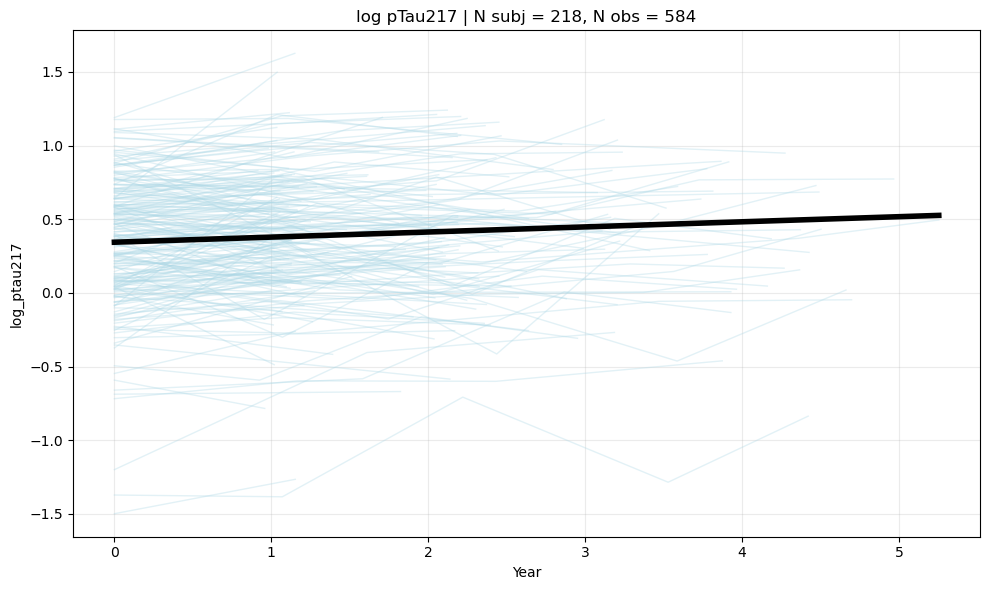

Standardized beta: 0.1703
p-value: 6.7825e-53
Marginal R²: 0.4799
Conditional R²: 0.9649


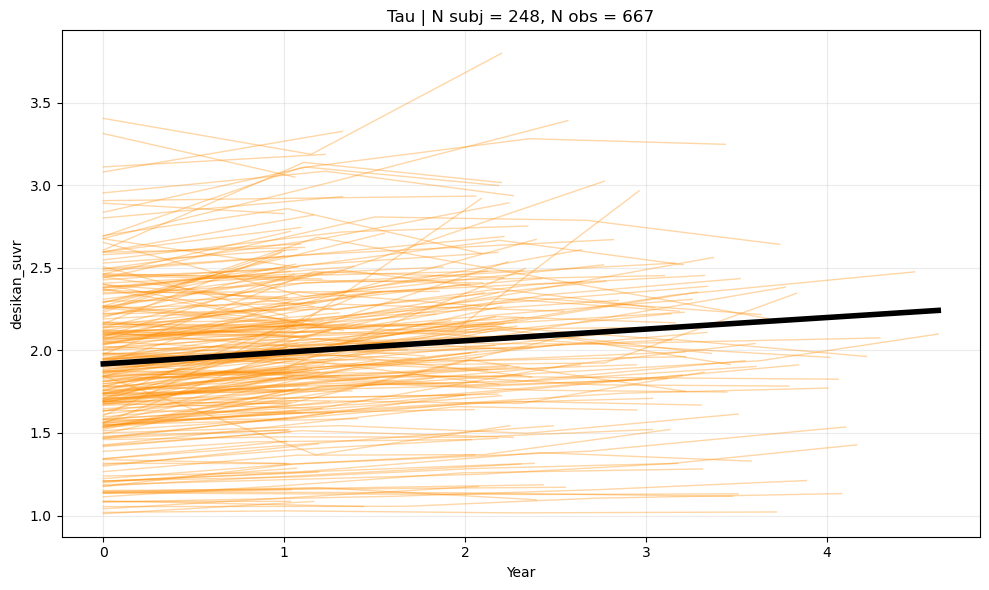

Standardized beta: 0.0869
p-value: 9.5321e-09
Marginal R²: 0.4567
Conditional R²: 0.9296


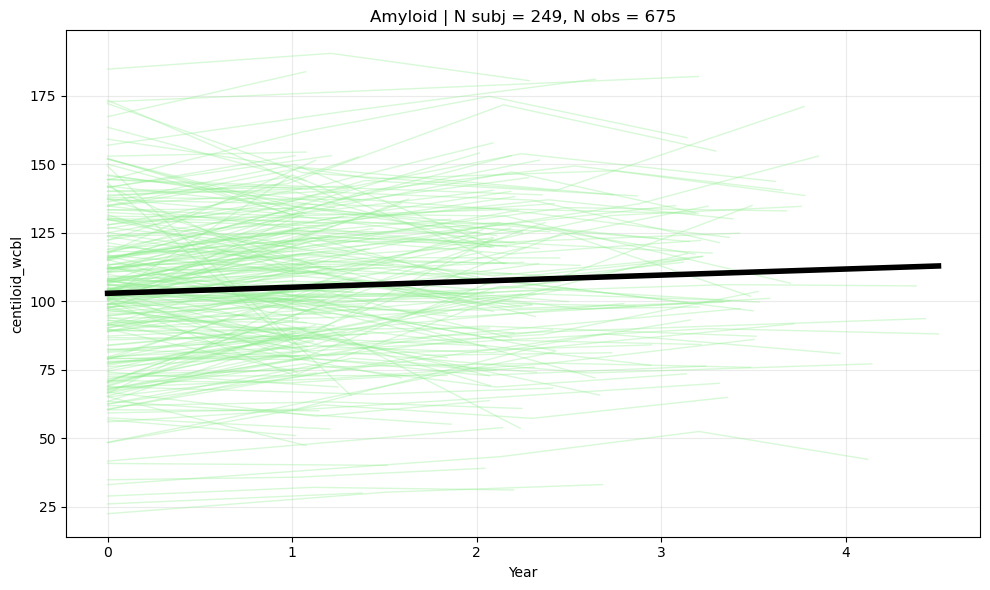

Standardized beta: 0.5775
p-value: 7.8689e-164
Marginal R²: 0.4964
Conditional R²: 0.7931


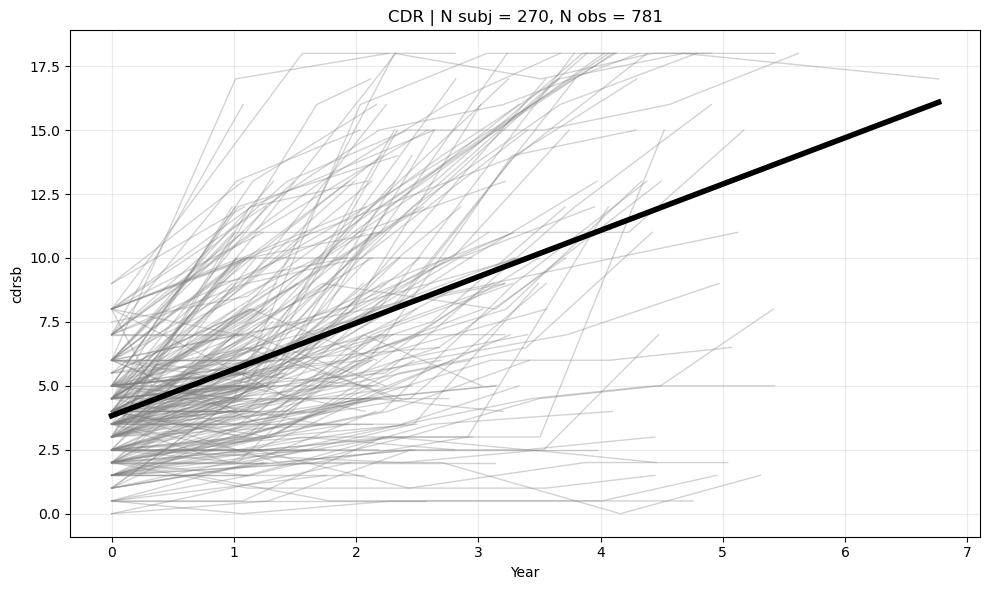

Standardized beta: -0.4281
p-value: 1.5506e-105
Marginal R²: 0.4690
Conditional R²: 0.9013


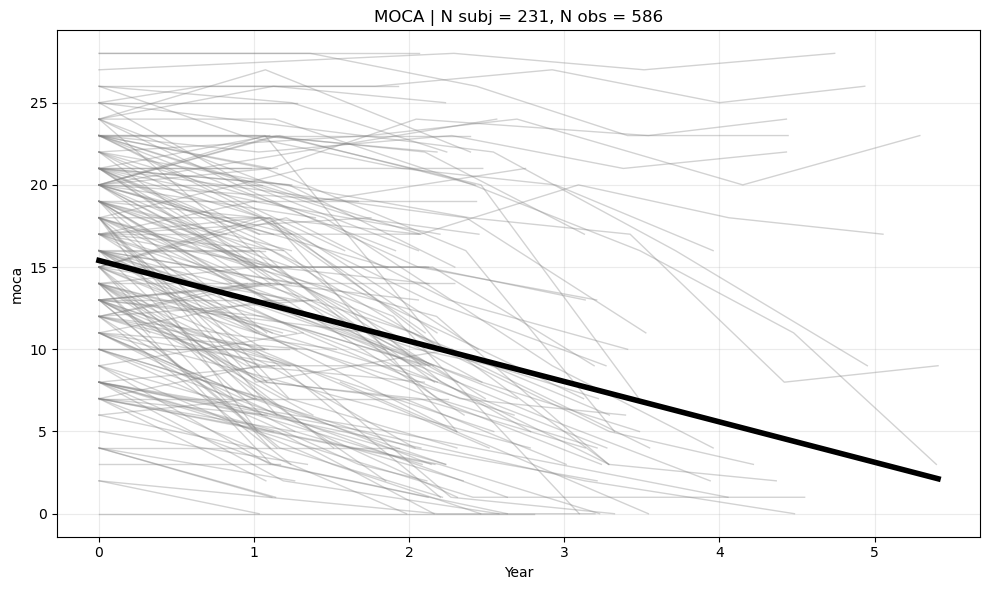

In [19]:
spaghetti_plot_colored(ptau_final, "subject_label", "year_to_baseline_ptau", "log_ptau217",
                       line_color="lightblue", title="log pTau217")

spaghetti_plot_colored(tau_final, "subject_label", "year_to_baseline_tau", "desikan_suvr",
                       line_color="darkorange", title="Tau")

spaghetti_plot_colored(amy_final, "subject_label", "year_to_baseline_amy", "centiloid_wcbl",
                       line_color="lightgreen", title="Amyloid")

spaghetti_plot_colored(cdr_final, "subject_label", "year_to_baseline_cdr", "cdrsb",
                       line_color="gray", title="CDR")

spaghetti_plot_colored(moca_final, "subject_label", "year_to_baseline_moca", "moca",
                       line_color="gray", title="MOCA")